<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%204/L2_Why_CNNs_and_Conv_Variants.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=jGbVN6LOYj4) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%204/NPTEL_Jul24_DL4CV_W04_P01.pdf)

In [ ]:
# Week 4, Lecture 2: CNN's Part 2
from IPython.display import HTML, display

VIDEO_ID = "jGbVN6LOYj4"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

Watch on YouTube

# Week 4, Lecture 2: Why CNNs? Local Receptive Fields, Weight Sharing, Pooling, and Convolution Variants

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§4.1 Introduction to CNNs**.

**What you will learn**
- Why we move from handcrafted features (SIFT, LBP, HoG) to *learned* filters.
- Why flattening an image into a fully connected network (FNN) is wasteful and ignores 2D structure.
- The three core ideas that make CNNs work: local receptive fields, weight sharing, and pooling.
- How a tiny CNN condenses an image stage by stage.
- Useful convolution variants: dilated, transpose, depthwise-separable, and grouped convolution.

**How to run**
- Run the cells top to bottom. On Google Colab the interactive sliders work automatically.
- Each idea is shown first from scratch and then checked against the PyTorch built-in.
- Everything uses tiny synthetic tensors, so the whole notebook runs in a minute or two on CPU.

**Contents**

1. From handcrafted filters to learned filters
2. Why not just flatten the image into a fully connected network?
3. Idea 1: Local receptive fields (sparse connectivity)
4. Idea 2: Weight sharing (translation equivariance)
5. Idea 3: Pooling (parameter-free downsampling)
6. Putting it together: a tiny CNN
7. Convolution variants


## Review

The previous lecture built the convolution operation and its hyperparameters, ending with the
output-size formula $W_2 = \frac{W_1 - F + 2P}{S} + 1$. This lecture takes those mechanics as given
and asks *why* a convolutional layer is the right thing to put on an image.

## Setup
Imports, inline plotting, seeds for reproducibility, and device selection (works on CPU and GPU).

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
from ipywidgets import interact, IntSlider, Dropdown

torch.manual_seed(0)
np.random.seed(0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print('torch version:', torch.__version__)

Using device: cpu
torch version: 2.8.0


## 1. From handcrafted filters to learned filters
- Classic vision hand-designed features: SIFT, LBP, HoG. Effective, but a fixed, manual bottleneck.
- Key idea of CNNs: do not hand-pick the kernels. Treat the kernel entries as **parameters** and learn
  them by gradient descent, jointly with the classifier (backprop, covered next lecture).
- First we apply a fixed Sobel edge kernel to a synthetic shape (this is feature engineering).
- Then we train a single `nn.Conv2d` to reproduce that edge response and watch it *become* an edge detector.

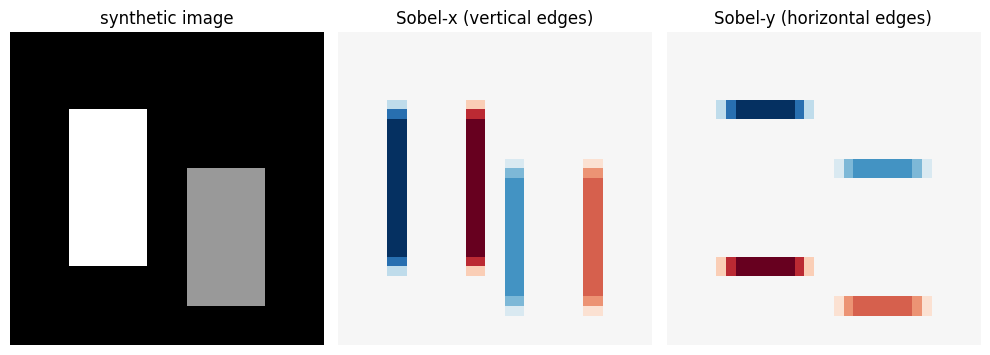

In [2]:
# A small synthetic image with clear edges (no external files).
def make_shape_image(size=32):
    img = np.zeros((size, size), dtype=np.float32)
    img[8:24, 6:14] = 1.0    # a bright block
    img[14:28, 18:26] = 0.6  # a second, dimmer block -> more edges
    return img

img = make_shape_image(32)

# Fixed, handcrafted edge kernels (feature engineering).
sobel_x = torch.tensor([[-1., 0., 1.],
                        [-2., 0., 2.],
                        [-1., 0., 1.]])
sobel_y = torch.tensor([[-1., -2., -1.],
                        [ 0.,  0.,  0.],
                        [ 1.,  2.,  1.]])

x = torch.from_numpy(img)[None, None]                      # shape (1, 1, H, W)
resp_x = F.conv2d(x, sobel_x[None, None], padding=1)[0, 0]  # vertical edges
resp_y = F.conv2d(x, sobel_y[None, None], padding=1)[0, 0]  # horizontal edges

fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
axes[0].imshow(img, cmap='gray');          axes[0].set_title('synthetic image')
axes[1].imshow(resp_x, cmap='RdBu');       axes[1].set_title('Sobel-x (vertical edges)')
axes[2].imshow(resp_y, cmap='RdBu');       axes[2].set_title('Sobel-y (horizontal edges)')
for a in axes: a.axis('off')
plt.tight_layout(); plt.show()

**Now learn the filter.** We feed random images to a single untrained `nn.Conv2d` and ask it to
reproduce the output of the known Sobel-x kernel. Because the inputs are random, the 3x3 kernel is
uniquely determined, so gradient descent should recover the edge detector itself.

In [3]:
# Build a supervised target: response of the known Sobel-x kernel on random images.
torch.manual_seed(0)
N = 64
train_imgs = torch.rand(N, 1, 16, 16)
target_kernel = sobel_x[None, None]
with torch.no_grad():
    targets = F.conv2d(train_imgs, target_kernel, padding=1)

# A single conv filter, randomly initialised.
conv = nn.Conv2d(1, 1, kernel_size=3, padding=1, bias=False)
kernel_before = conv.weight.detach().clone().squeeze().numpy()

conv = conv.to(device)
train_imgs_d, targets_d = train_imgs.to(device), targets.to(device)
opt = torch.optim.Adam(conv.parameters(), lr=0.08)

losses = []
for step in range(400):
    opt.zero_grad()
    loss = F.mse_loss(conv(train_imgs_d), targets_d)
    loss.backward()
    opt.step()
    losses.append(loss.item())

kernel_after = conv.weight.detach().cpu().squeeze().numpy()
print('final MSE loss:', round(losses[-1], 8))
print('max |learned - target|:', round(float(np.abs(kernel_after - sobel_x.numpy()).max()), 4))
print('learned kernel:\n', np.round(kernel_after, 2))
print('target  kernel:\n', sobel_x.numpy())

final MSE loss: 0.0
max |learned - target|: 0.0
learned kernel:
 [[-1.  0.  1.]
 [-2.  0.  2.]
 [-1.  0.  1.]]
target  kernel:
 [[-1.  0.  1.]
 [-2.  0.  2.]
 [-1.  0.  1.]]


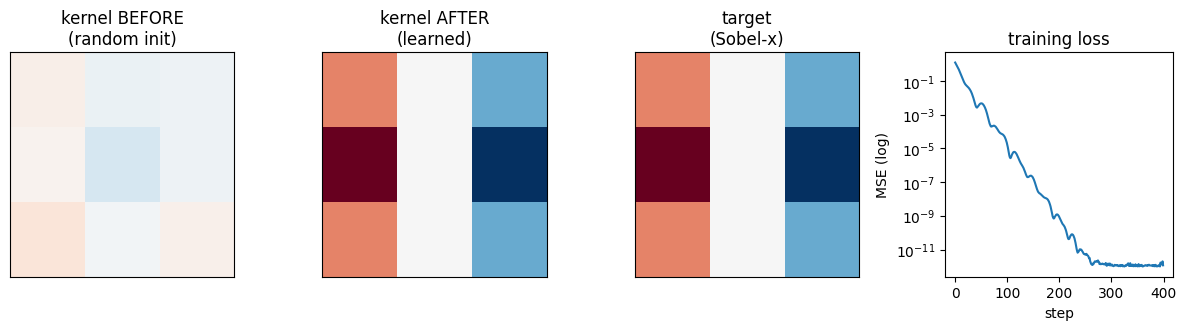

The learned filter matched the handcrafted edge detector, discovered purely by gradient descent.


In [4]:
# Visualise: kernel before vs after training, the target, and the loss curve.
vmax = np.abs(sobel_x.numpy()).max()
fig, axes = plt.subplots(1, 4, figsize=(12, 3.2))
axes[0].imshow(kernel_before, cmap='RdBu', vmin=-vmax, vmax=vmax); axes[0].set_title('kernel BEFORE\n(random init)')
axes[1].imshow(kernel_after,  cmap='RdBu', vmin=-vmax, vmax=vmax); axes[1].set_title('kernel AFTER\n(learned)')
axes[2].imshow(sobel_x.numpy(), cmap='RdBu', vmin=-vmax, vmax=vmax); axes[2].set_title('target\n(Sobel-x)')
for a in axes[:3]: a.set_xticks([]); a.set_yticks([])
axes[3].plot(losses); axes[3].set_yscale('log')
axes[3].set_title('training loss'); axes[3].set_xlabel('step'); axes[3].set_ylabel('MSE (log)')
plt.tight_layout(); plt.show()
print('The learned filter matched the handcrafted edge detector, discovered purely by gradient descent.')

## 2. Why not just flatten the image into a fully connected network?
- Flattening a $28 \times 28$ image into a 784 vector throws away 2D structure: adjacent and far pixels
  are treated the same way.
- There is no natural way to reuse the same feature (for example an edge) at different locations.
- Parameter blow-up: a 1 megapixel colour image ($1000 \times 1000 \times 3$) feeding 20 hidden units
  needs $1000 \cdot 1000 \cdot 3 \cdot 20 = 60{,}000{,}000$ weights in the first layer alone.
- A convolution layer needs only $K \times K \times C$ weights per filter, independent of image size.

FNN first-layer weights : 60,000,000
Conv (3x3, 20 filters): 540
FNN uses about 111,111x more weights than the conv layer.


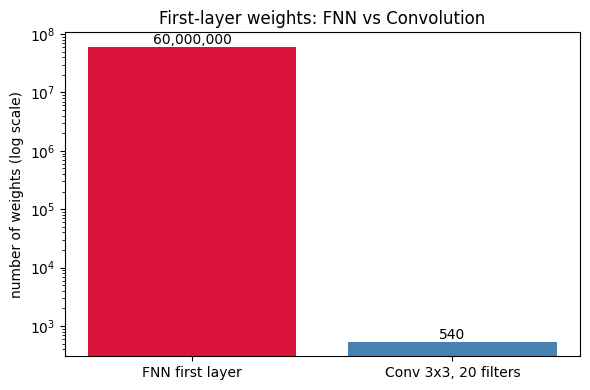

In [5]:
# Reproduce the 60 million example from the slides.
def fnn_first_layer_weights(H, W, C, hidden):
    return H * W * C * hidden

def conv_layer_weights(K, C, filters):
    return K * K * C * filters

H, W, C, hidden = 1000, 1000, 3, 20      # 1 megapixel colour image, 20 hidden units
K, filters = 3, 20                        # a 3x3 conv layer with 20 filters
fnn = fnn_first_layer_weights(H, W, C, hidden)
conv_w = conv_layer_weights(K, C, filters)

print(f'FNN first-layer weights : {fnn:,}')
print(f'Conv (3x3, {filters} filters): {conv_w:,}')
print(f'FNN uses about {fnn // conv_w:,}x more weights than the conv layer.')

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['FNN first layer', 'Conv 3x3, 20 filters'], [fnn, conv_w],
              color=['crimson', 'steelblue'])
ax.set_yscale('log'); ax.set_ylabel('number of weights (log scale)')
ax.set_title('First-layer weights: FNN vs Convolution')
for b, v in zip(bars, [fnn, conv_w]):
    ax.text(b.get_x() + b.get_width()/2, v, f'{v:,}', ha='center', va='bottom')
plt.tight_layout(); plt.show()

**Interactive calculator.** Move the sliders for image height, width, channels, and hidden units.
The FNN first-layer count is $H \cdot W \cdot C \cdot \text{hidden}$; the conv count
($K \times K \times C \times \text{filters}$, with $K=3$) barely moves because it does not depend on image size.

In [6]:
def show_param_explosion(H=1000, W=1000, C=3, hidden=20):
    K = 3
    fnn = H * W * C * hidden
    conv_w = K * K * C * hidden   # 'hidden' filters, for a fair comparison
    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar([f'FNN ({H}x{W}x{C} -> {hidden})', f'Conv (3x3x{C}, {hidden} filters)'],
                  [fnn, conv_w], color=['crimson', 'steelblue'])
    ax.set_yscale('log'); ax.set_ylabel('weights (log scale)')
    ax.set_title(f'FNN {fnn:,}   vs   Conv {conv_w:,}')
    for b, v in zip(bars, [fnn, conv_w]):
        ax.text(b.get_x() + b.get_width()/2, v, f'{v:,}', ha='center', va='bottom')
    plt.tight_layout(); plt.show()

interact(show_param_explosion,
         H=IntSlider(min=28, max=2000, step=28, value=1000),
         W=IntSlider(min=28, max=2000, step=28, value=1000),
         C=IntSlider(min=1, max=3, step=1, value=3),
         hidden=IntSlider(min=1, max=100, step=1, value=20));

interactive(children=(IntSlider(value=1000, description='H', max=2000, min=28, step=28), IntSlider(value=1000,…

## 3. Idea 1: Local receptive fields (sparse connectivity)
- Each hidden unit connects only to a small local patch of the input, not to every pixel.
- This captures local spatial relationships and slashes the parameter count.
- Slide example on a 4x4 input: only pixels 1, 2, 5, 6 feed the first hidden unit $h_{11}$.
- Distant pixels are not lost: they interact **indirectly** through deeper layers, so the effective
  receptive field grows with depth.

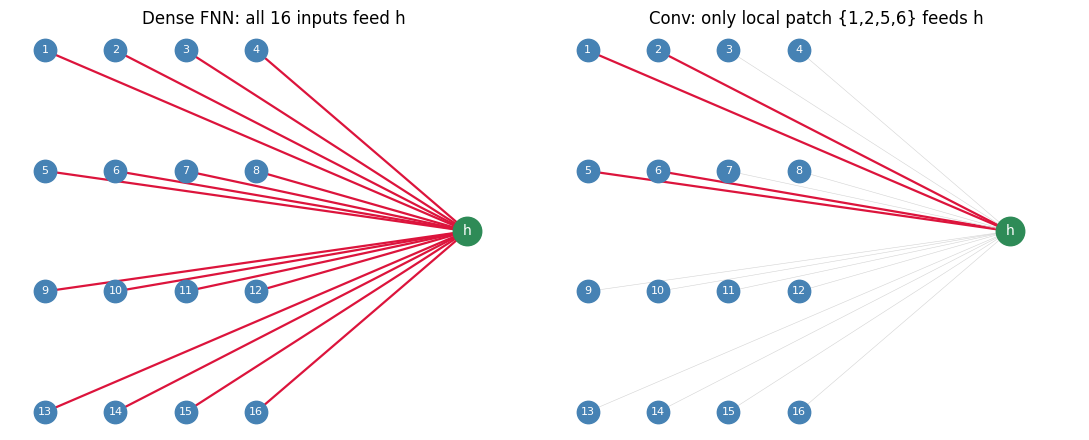

In [7]:
# Compare dense (FNN) vs sparse (conv) connectivity into ONE hidden unit on a 4x4 input.
def draw_connectivity(ax, active_inputs, title, grid=4):
    pos = {}
    idx = 1
    for r in range(grid):
        for c in range(grid):
            pos[idx] = (c, grid - 1 - r)   # index 1..16, row-major
            idx += 1
    out_pos = (grid + 2, (grid - 1) / 2)
    for i, (px, py) in pos.items():
        on = i in active_inputs
        ax.plot([px, out_pos[0]], [py, out_pos[1]],
                color='crimson' if on else 'lightgray',
                lw=1.6 if on else 0.4, zorder=1)
    xs = [p[0] for p in pos.values()]; ys = [p[1] for p in pos.values()]
    ax.scatter(xs, ys, s=260, c='steelblue', zorder=2)
    for i, (px, py) in pos.items():
        ax.text(px, py, str(i), ha='center', va='center', color='white', fontsize=8, zorder=3)
    ax.scatter([out_pos[0]], [out_pos[1]], s=420, c='seagreen', zorder=2)
    ax.text(out_pos[0], out_pos[1], 'h', ha='center', va='center', color='white', zorder=3)
    ax.set_title(title); ax.axis('off'); ax.set_xlim(-0.5, grid + 3)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
draw_connectivity(axes[0], set(range(1, 17)), 'Dense FNN: all 16 inputs feed h')
draw_connectivity(axes[1], {1, 2, 5, 6},      'Conv: only local patch {1,2,5,6} feeds h')
plt.tight_layout(); plt.show()

**Interactive receptive field.** Pick an output unit of a conv layer (kernel size $K$, stride 1) on a
4x4 input and see exactly which input pixels feed it.

In [8]:
def show_rf(out_row=0, out_col=0, K=2):
    grid = 4
    out_row = min(out_row, grid - K)   # clamp so the patch stays inside the image
    out_col = min(out_col, grid - K)
    highlight = np.zeros((grid, grid))
    highlight[out_row:out_row + K, out_col:out_col + K] = 1.0
    fig, ax = plt.subplots(figsize=(4.2, 4.2))
    ax.imshow(highlight, cmap='Reds', vmin=0, vmax=1)
    for r in range(grid):
        for c in range(grid):
            ax.text(c, r, str(r * grid + c + 1), ha='center', va='center',
                    color='black', fontsize=9)
    ax.set_xticks(range(grid)); ax.set_yticks(range(grid))
    ax.set_title(f'Output ({out_row},{out_col}) sees rows {out_row}-{out_row+K-1}, '
                 f'cols {out_col}-{out_col+K-1}\n({K*K} input pixels, not all 16)')
    plt.tight_layout(); plt.show()

interact(show_rf,
         out_row=IntSlider(min=0, max=2, step=1, value=0),
         out_col=IntSlider(min=0, max=2, step=1, value=0),
         K=IntSlider(min=2, max=3, step=1, value=2));

interactive(children=(IntSlider(value=0, description='out_row', max=2), IntSlider(value=0, description='out_co…

**Depth grows the receptive field.** Two highlighted pixels that do not interact in layer 1 still
influence a shared unit deeper in the network. Stacking $L$ layers of $K \times K$ convolutions
(stride 1) gives an effective receptive field of $1 + L(K-1)$.

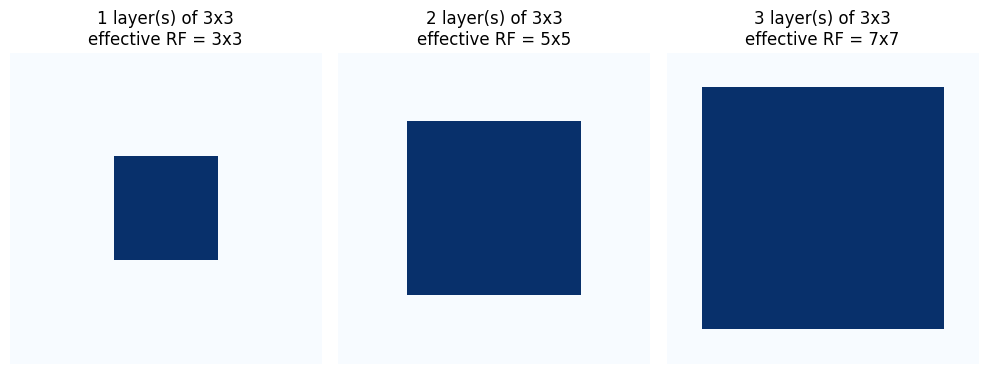

Distant pixels interact indirectly: the receptive field widens as we stack layers.


In [9]:
def rf_size(L, K=3):
    return 1 + L * (K - 1)

G, center = 9, 4
fig, axes = plt.subplots(1, 3, figsize=(10, 3.6))
for ax, L in zip(axes, [1, 2, 3]):
    half = rf_size(L) // 2
    m = np.zeros((G, G))
    m[center - half:center + half + 1, center - half:center + half + 1] = 1
    ax.imshow(m, cmap='Blues'); ax.axis('off')
    ax.set_title(f'{L} layer(s) of 3x3\neffective RF = {rf_size(L)}x{rf_size(L)}')
plt.tight_layout(); plt.show()
print('Distant pixels interact indirectly: the receptive field widens as we stack layers.')

## 4. Idea 2: Weight sharing (translation equivariance)
- The same filter is slid across every location, so it detects a feature wherever it appears.
- This gives translation equivariance: shift the input and the response shifts the same way.
- One filter costs only $K \times K$ weights no matter how large the image is.
- Use many filters to capture many kinds of features, each one applied everywhere.

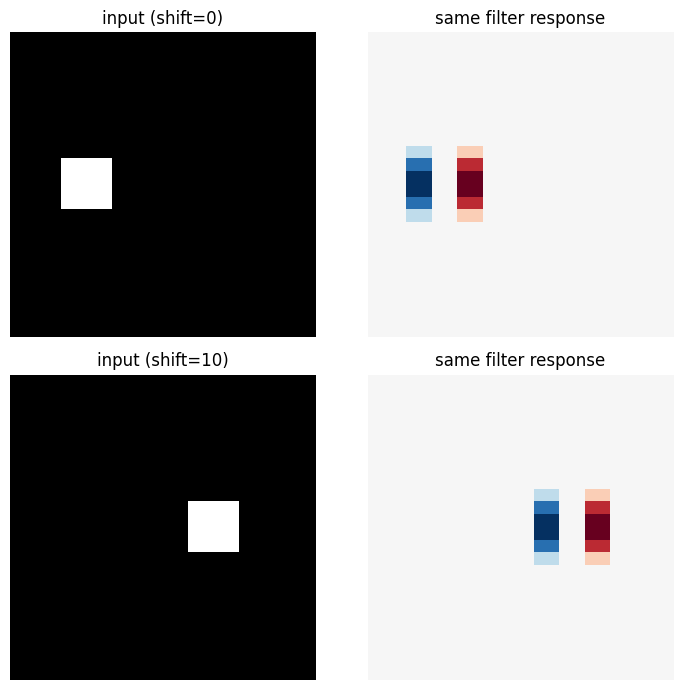

The filter responds identically to the shape, just moved: translation equivariance.


In [10]:
# A small shape, shifted; the SAME filter gives a response that shifts with it.
def make_bar_image(size=24, row=10, col=4, w=4, h=4):
    im = np.zeros((size, size), dtype=np.float32)
    im[row:row + h, col:col + w] = 1.0
    return im

fig, axes = plt.subplots(2, 2, figsize=(7.5, 7))
for k, shift in enumerate([0, 10]):
    im = make_bar_image(col=4 + shift)
    r = F.conv2d(torch.from_numpy(im)[None, None], sobel_x[None, None], padding=1)[0, 0]
    axes[k, 0].imshow(im, cmap='gray');  axes[k, 0].set_title(f'input (shift={shift})')
    axes[k, 1].imshow(r, cmap='RdBu');   axes[k, 1].set_title('same filter response')
    for a in axes[k]: a.axis('off')
plt.tight_layout(); plt.show()
print('The filter responds identically to the shape, just moved: translation equivariance.')

**Interactive shift.** Drag the shift slider and watch the input and its feature map move together
because the SAME weights are used everywhere.

In [11]:
def show_shift(shift=0):
    im = make_bar_image(size=24, col=4 + shift)
    r = F.conv2d(torch.from_numpy(im)[None, None], sobel_x[None, None], padding=1)[0, 0]
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(im, cmap='gray'); axes[0].set_title(f'input (shift={shift})')
    axes[1].imshow(r, cmap='RdBu');  axes[1].set_title('feature map (shifts too)')
    for a in axes: a.axis('off')
    plt.tight_layout(); plt.show()

interact(show_shift, shift=IntSlider(min=0, max=14, step=1, value=0));

interactive(children=(IntSlider(value=0, description='shift', max=14), Output()), _dom_classes=('widget-intera…

In [12]:
# With vs without weight sharing: parameter count for one 3x3 filter on a 28x28 input.
H = W = 28; K = 3
out_H = out_W = H - K + 1                     # 26x26 output positions
without_sharing = out_H * out_W * K * K       # a separate 3x3 kernel per position
with_sharing = K * K                          # one shared 3x3 kernel
print(f'Without weight sharing (locally connected): {without_sharing:,} weights')
print(f'With weight sharing (convolution):          {with_sharing} weights')
print(f'Weight sharing is about {without_sharing // with_sharing:,}x smaller here.')

Without weight sharing (locally connected): 6,084 weights
With weight sharing (convolution):          9 weights
Weight sharing is about 676x smaller here.


## 5. Idea 3: Pooling (parameter-free downsampling)
- Pooling condenses a feature map by summarizing each window with a single number.
- Common types: max, average, and L2 pooling. (Also mixed, spatial-pyramid, and spectral pooling, seen later.)
- It has no learnable parameters, adds robustness to small shifts, and shrinks maps to cut later compute.
- We implement max and average pooling with explicit loops, then confirm against the PyTorch built-ins.

max pooling matches F.max_pool2d: True
avg pooling matches F.avg_pool2d: True


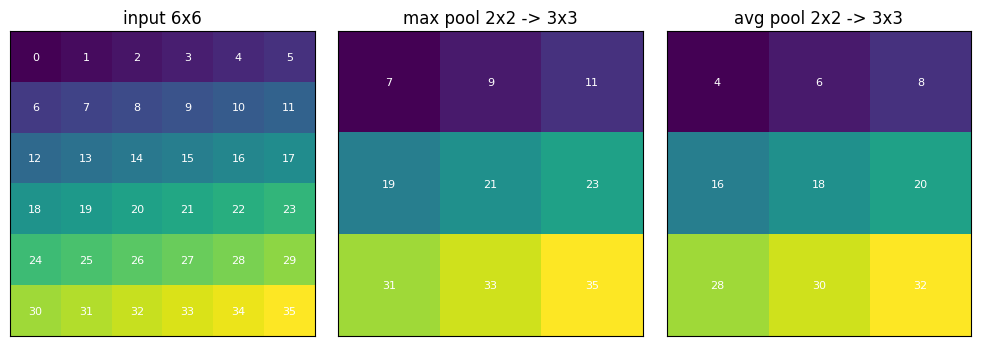

In [13]:
def max_pool2d_scratch(x, k, s):
    H, W = x.shape
    out_H, out_W = (H - k) // s + 1, (W - k) // s + 1
    out = np.zeros((out_H, out_W), dtype=x.dtype)
    for i in range(out_H):
        for j in range(out_W):
            out[i, j] = x[i*s:i*s+k, j*s:j*s+k].max()
    return out

def avg_pool2d_scratch(x, k, s):
    H, W = x.shape
    out_H, out_W = (H - k) // s + 1, (W - k) // s + 1
    out = np.zeros((out_H, out_W), dtype=x.dtype)
    for i in range(out_H):
        for j in range(out_W):
            out[i, j] = x[i*s:i*s+k, j*s:j*s+k].mean()
    return out

m = np.arange(36, dtype=np.float32).reshape(6, 6)
mine_max = max_pool2d_scratch(m, 2, 2)
mine_avg = avg_pool2d_scratch(m, 2, 2)

t = torch.from_numpy(m)[None, None]
ref_max = F.max_pool2d(t, kernel_size=2, stride=2)[0, 0].numpy()
ref_avg = F.avg_pool2d(t, kernel_size=2, stride=2)[0, 0].numpy()

print('max pooling matches F.max_pool2d:', torch.allclose(torch.tensor(mine_max), torch.tensor(ref_max)))
print('avg pooling matches F.avg_pool2d:', torch.allclose(torch.tensor(mine_avg), torch.tensor(ref_avg)))

fig, axes = plt.subplots(1, 3, figsize=(10, 3.4))
for ax, data, title in zip(axes, [m, mine_max, mine_avg],
                           ['input 6x6', 'max pool 2x2 -> 3x3', 'avg pool 2x2 -> 3x3']):
    ax.imshow(data, cmap='viridis'); ax.set_title(title)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, f'{data[i, j]:.0f}', ha='center', va='center', color='white', fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

**Interactive pooling.** Choose the pooling type and the window and stride. L2 pooling reports
$\sqrt{\sum x^2}$ over each window.

In [14]:
def show_pool(pool_type='max', k=2, s=2):
    rng = np.random.RandomState(0)
    m = rng.rand(8, 8).astype(np.float32)
    t = torch.from_numpy(m)[None, None]
    if pool_type == 'max':
        out = F.max_pool2d(t, kernel_size=k, stride=s)
    elif pool_type == 'avg':
        out = F.avg_pool2d(t, kernel_size=k, stride=s)
    else:  # L2 pooling: sqrt of the sum of squares in each window
        out = torch.sqrt(F.avg_pool2d(t**2, kernel_size=k, stride=s) * (k * k))
    out = out[0, 0].numpy()
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(m, cmap='viridis');  axes[0].set_title('input 8x8')
    axes[1].imshow(out, cmap='viridis'); axes[1].set_title(f'{pool_type} pool k={k}, s={s} -> {out.shape}')
    for a in axes: a.set_xticks([]); a.set_yticks([])
    plt.tight_layout(); plt.show()

interact(show_pool,
         pool_type=Dropdown(options=['max', 'avg', 'L2'], value='max'),
         k=IntSlider(min=1, max=4, step=1, value=2),
         s=IntSlider(min=1, max=4, step=1, value=2));

interactive(children=(Dropdown(description='pool_type', options=('max', 'avg', 'L2'), value='max'), IntSlider(…

max abs difference between the two pooled maps: 0.2819


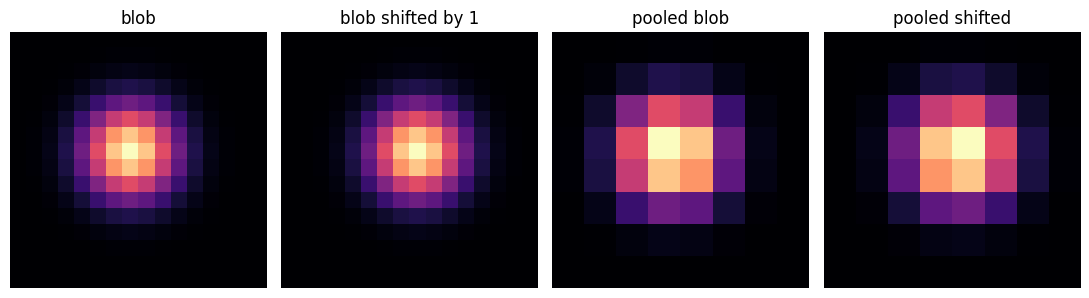

In [15]:
# Small-shift robustness: shift a blob by one pixel, then max pool. The pooled map barely changes.
yy, xx = np.mgrid[0:16, 0:16]
blob    = np.exp(-((xx - 7)**2 + (yy - 7)**2) / 8.0).astype(np.float32)
shifted = np.exp(-((xx - 8)**2 + (yy - 7)**2) / 8.0).astype(np.float32)   # moved right by 1

p1 = F.max_pool2d(torch.from_numpy(blob)[None, None],    kernel_size=2, stride=2)[0, 0].numpy()
p2 = F.max_pool2d(torch.from_numpy(shifted)[None, None], kernel_size=2, stride=2)[0, 0].numpy()
print('max abs difference between the two pooled maps:', round(float(np.abs(p1 - p2).max()), 4))

fig, axes = plt.subplots(1, 4, figsize=(11, 3))
for ax, d, t in zip(axes, [blob, shifted, p1, p2],
                    ['blob', 'blob shifted by 1', 'pooled blob', 'pooled shifted']):
    ax.imshow(d, cmap='magma'); ax.set_title(t); ax.axis('off')
plt.tight_layout(); plt.show()

## 6. Putting it together: a tiny CNN
- A typical CNN alternates convolution and pooling layers, then flattens into a classifier.
- Below: conv -> relu -> pool -> conv -> relu -> pool -> flatten -> fully connected.
- We print the tensor shape after every stage to watch the map condense, and visualize feature maps.
- The weights are randomly initialised (untrained), so we only inspect shapes and activations here.

In [16]:
torch.manual_seed(0)
conv1 = nn.Conv2d(1, 4, kernel_size=3, padding=1).to(device)
conv2 = nn.Conv2d(4, 8, kernel_size=3, padding=1).to(device)
fc    = nn.Linear(8 * 7 * 7, 10).to(device)

x = torch.from_numpy(make_shape_image(28))[None, None].to(device)
print('input           ', tuple(x.shape))
a1 = F.relu(conv1(x));            print('after conv1+relu', tuple(a1.shape))
p1 = F.max_pool2d(a1, 2);         print('after pool1     ', tuple(p1.shape))
a2 = F.relu(conv2(p1));           print('after conv2+relu', tuple(a2.shape))
p2 = F.max_pool2d(a2, 2);         print('after pool2     ', tuple(p2.shape))
flat = p2.flatten(1);             print('after flatten   ', tuple(flat.shape))
logits = fc(flat);                print('logits          ', tuple(logits.shape))

input            (1, 1, 28, 28)
after conv1+relu (1, 4, 28, 28)
after pool1      (1, 4, 14, 14)
after conv2+relu (1, 8, 14, 14)
after pool2      (1, 8, 7, 7)
after flatten    (1, 392)
logits           (1, 10)


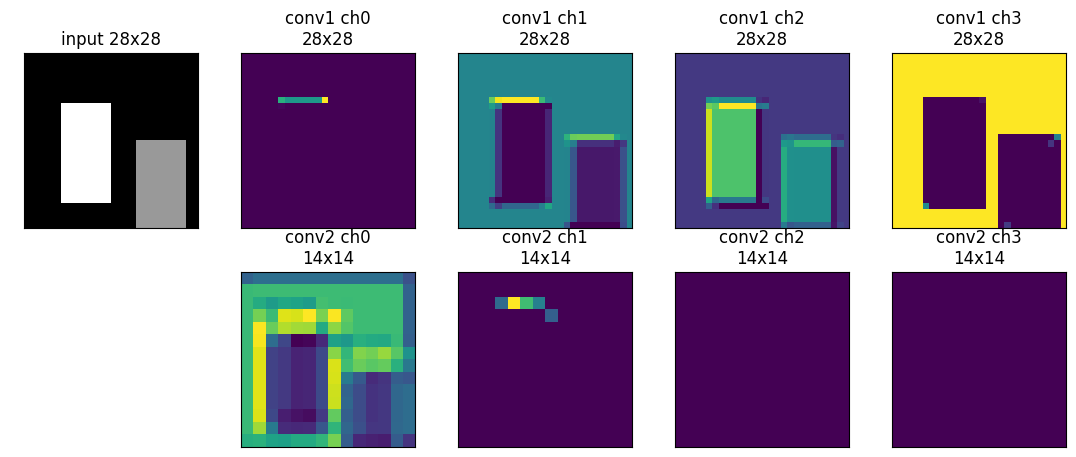

In [17]:
# Visualise how the spatial maps shrink while the number of channels grows.
a1n = a1.detach().cpu()[0]
a2n = a2.detach().cpu()[0]
fig, axes = plt.subplots(2, 5, figsize=(11, 4.6))
axes[0, 0].imshow(x.detach().cpu()[0, 0], cmap='gray'); axes[0, 0].set_title('input 28x28')
for c in range(4):
    axes[0, c + 1].imshow(a1n[c], cmap='viridis'); axes[0, c + 1].set_title(f'conv1 ch{c}\n28x28')
axes[1, 0].axis('off')
for c in range(4):
    axes[1, c + 1].imshow(a2n[c], cmap='viridis'); axes[1, c + 1].set_title(f'conv2 ch{c}\n14x14')
for a in axes.ravel(): a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

## 7. Convolution variants
A few practical relatives of the standard convolution.

### 7a. Dilated convolution
- Adds a dilation rate $d$ that spaces out the kernel taps. Dilation 1 is standard convolution.
- It enlarges the receptive field **without subsampling**, which is the subtle difference from stride
  greater than 1.
- Stride greater than 1 skips output positions and shrinks the map; dilation keeps stride 1 and keeps
  the resolution while seeing a wider area. A $K \times K$ kernel with dilation $d$ has an effective
  size $d(K-1)+1$.

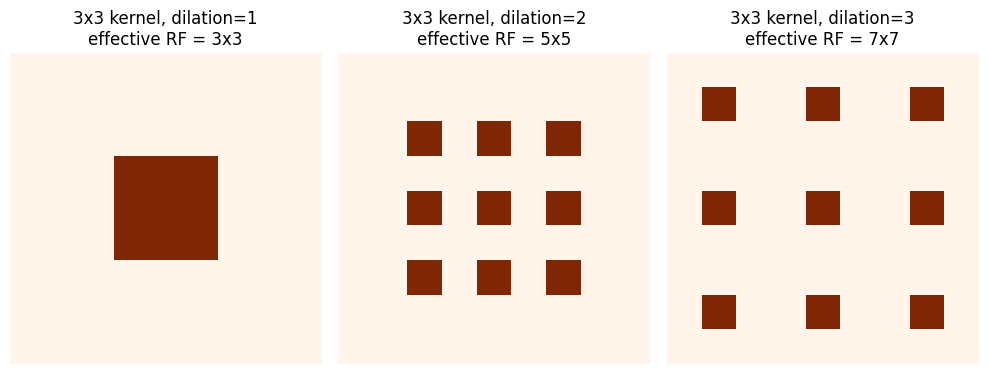

dilation=1: effective kernel 3x3, input 16x16 -> output (14, 14) (stride stays 1, map stays large)
dilation=2: effective kernel 5x5, input 16x16 -> output (12, 12) (stride stays 1, map stays large)
dilation=3: effective kernel 7x7, input 16x16 -> output (10, 10) (stride stays 1, map stays large)


In [18]:
def dilated_footprint(K=3, d=1, size=9):
    m = np.zeros((size, size))
    center = size // 2
    start = center - (d * (K - 1)) // 2
    for i in range(K):
        for j in range(K):
            m[start + i*d, start + j*d] = 1.0
    return m

fig, axes = plt.subplots(1, 3, figsize=(10, 3.6))
for ax, d in zip(axes, [1, 2, 3]):
    ax.imshow(dilated_footprint(3, d, 9), cmap='Oranges')
    eff = d * 2 + 1
    ax.set_title(f'3x3 kernel, dilation={d}\neffective RF = {eff}x{eff}'); ax.axis('off')
plt.tight_layout(); plt.show()

# Confirm receptive field and output size with the real layer (stride 1, no padding).
for d in [1, 2, 3]:
    out = nn.Conv2d(1, 1, kernel_size=3, dilation=d)(torch.zeros(1, 1, 16, 16))
    print(f'dilation={d}: effective kernel {d*2+1}x{d*2+1}, '
          f'input 16x16 -> output {tuple(out.shape[2:])} (stride stays 1, map stays large)')

**Interactive dilation.** Slide the dilation rate and watch the kernel footprint spread out over the grid.

In [19]:
def show_dilation(d=2):
    fig, ax = plt.subplots(figsize=(4.2, 4.2))
    ax.imshow(dilated_footprint(3, d, 9), cmap='Oranges')
    eff = d * 2 + 1
    ax.set_title(f'3x3 kernel, dilation={d}, effective RF = {eff}x{eff}')
    ax.set_xticks(range(9)); ax.set_yticks(range(9))
    plt.tight_layout(); plt.show()

interact(show_dilation, d=IntSlider(min=1, max=3, step=1, value=2));

interactive(children=(IntSlider(value=2, description='d', max=3, min=1), Output()), _dom_classes=('widget-inte…

### 7b. Transpose convolution
- Learnable upsampling. Also called deconvolution (a poor name) or upconvolution.
- Instead of a fixed interpolation rule, the network learns how to fill in the upsampled values.
- Output size grows as $H_{out} = (H_{in} - 1)\cdot S - 2P + K$.

input 2x2 -> output (5, 5) (learnable upsampling)


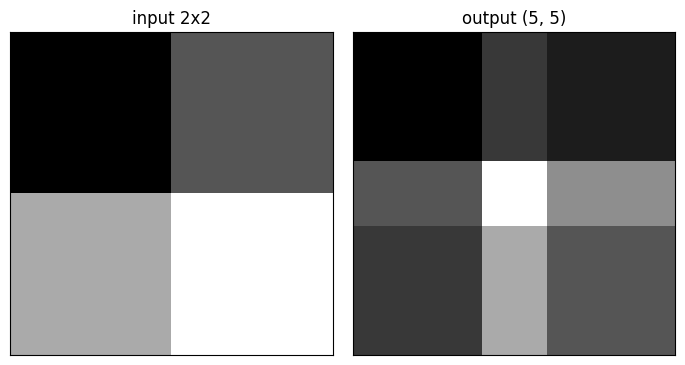

In [20]:
# Upsample a 2x2 input to a larger map with a learnable transpose conv.
inp = torch.tensor([[1., 2.], [3., 4.]])[None, None]
deconv = nn.ConvTranspose2d(1, 1, kernel_size=3, stride=2, bias=False)
with torch.no_grad():
    deconv.weight.fill_(1.0)   # fixed weights just to make the pattern visible
out = deconv(inp)
print('input 2x2 -> output', tuple(out.shape[2:]), '(learnable upsampling)')

fig, axes = plt.subplots(1, 2, figsize=(7, 3.6))
axes[0].imshow(inp[0, 0].numpy(), cmap='gray'); axes[0].set_title('input 2x2')
axes[1].imshow(out[0, 0].detach().numpy(), cmap='gray'); axes[1].set_title(f'output {tuple(out.shape[2:])}')
for a in axes: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

**Interactive transpose convolution.** Increase the stride to upsample more; padding crops the border.
Watch the output size grow.

In [21]:
def show_transpose(stride=2, padding=0):
    inp = torch.ones(1, 1, 4, 4)
    deconv = nn.ConvTranspose2d(1, 1, kernel_size=3, stride=stride, padding=padding, bias=False)
    with torch.no_grad():
        deconv.weight.fill_(1.0)
    out = deconv(inp)
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(inp[0, 0].numpy(), cmap='gray'); axes[0].set_title('input 4x4')
    axes[1].imshow(out[0, 0].detach().numpy(), cmap='gray')
    axes[1].set_title(f'stride={stride}, padding={padding} -> {tuple(out.shape[2:])}')
    for a in axes: a.set_xticks([]); a.set_yticks([])
    plt.tight_layout(); plt.show()

interact(show_transpose,
         stride=IntSlider(min=1, max=3, step=1, value=2),
         padding=IntSlider(min=0, max=2, step=1, value=0));

interactive(children=(IntSlider(value=2, description='stride', max=3, min=1), IntSlider(value=0, description='…

### 7c. Depthwise-separable and grouped convolution
- Depthwise-separable = a per-channel depthwise conv followed by a 1x1 pointwise conv. Far fewer parameters.
- Grouped convolution splits the channels into $g$ groups, dividing the parameter count by $g$.
- Below we count parameters for the same shapes and verify against real `nn.Conv2d` modules.

standard             : 18,432
depthwise-separable  : 2,336  (7.9x fewer)
grouped (g=4)        : 4,608  (4x fewer)


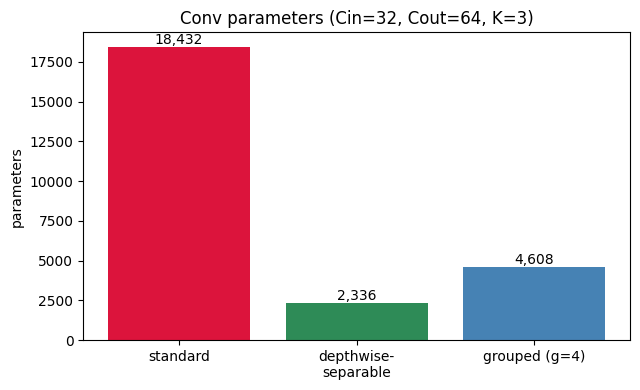

In [22]:
Cin, Cout, K, g = 32, 64, 3, 4

standard  = Cin * Cout * K * K
depthwise = Cin * K * K            # one KxK kernel per input channel
pointwise = Cin * Cout             # 1x1 conv mixing channels
dw_sep    = depthwise + pointwise
grouped   = (Cin // g) * (Cout // g) * K * K * g   # = standard / g

# Verify the hand counts against real PyTorch layers.
n = lambda mod: sum(p.numel() for p in mod.parameters())
assert n(nn.Conv2d(Cin, Cout, K, bias=False)) == standard
assert n(nn.Conv2d(Cin, Cin, K, groups=Cin, bias=False)) + n(nn.Conv2d(Cin, Cout, 1, bias=False)) == dw_sep
assert n(nn.Conv2d(Cin, Cout, K, groups=g, bias=False)) == grouped
print(f'standard             : {standard:,}')
print(f'depthwise-separable  : {dw_sep:,}  ({standard / dw_sep:.1f}x fewer)')
print(f'grouped (g={g})        : {grouped:,}  ({standard / grouped:.0f}x fewer)')

fig, ax = plt.subplots(figsize=(6.5, 4))
labels = ['standard', 'depthwise-\nseparable', f'grouped (g={g})']
vals = [standard, dw_sep, grouped]
bars = ax.bar(labels, vals, color=['crimson', 'seagreen', 'steelblue'])
ax.set_ylabel('parameters'); ax.set_title(f'Conv parameters (Cin={Cin}, Cout={Cout}, K={K})')
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v, f'{v:,}', ha='center', va='bottom')
plt.tight_layout(); plt.show()

## Key takeaways
- Handcrafted features (SIFT, LBP, HoG) work but are a manual bottleneck. CNNs learn the filters instead, via backprop.
- Flattening images into an FNN ignores 2D structure, cannot reuse features across locations, and explodes in parameters (the 60 million example).
- **Local receptive fields**: each unit sees a local patch. Sparse connectivity, far fewer parameters, and distant pixels still interact through depth.
- **Weight sharing**: one filter reused everywhere gives translation equivariance and only $K \times K$ weights per filter.
- **Pooling**: parameter-free downsampling (max, average, L2) that aggregates information, adds small-shift robustness, and shrinks maps.
- A typical CNN alternates convolution and pooling, then flattens into a classifier.
- Variants: dilated (wider receptive field, no subsampling), transpose (learnable upsampling), depthwise-separable and grouped (parameter savings).

## Exercises
- In the FNN calculator, push the image size up and watch the FNN weights explode while the conv count stays flat.
- Change the learned-filter target to `sobel_y` and see the kernel it recovers.
- In the pooling widget, compare max vs average vs L2 and vary the window and stride.
- In the dilated widget, confirm the effective receptive field is $d(K-1)+1$.
- In the transpose widget, find settings that upsample a 4x4 input to 8x8 or larger.

**Open question (teaser for the backprop lecture)**: max pooling only passes the maximum value forward,
so is it differentiable, and how do we backpropagate through it? We answer this in the next notebook.